- Name: Akanksha Tomar
- Student ID: 35679220

In [ ]:
# Install required packages, if you haven't installed them
! pip install uv
! uv pip install torchinfo
! uv pip install transformers==4.57.6 --no-deps --no-cache-dir
! uv pip install huggingface_hub==0.36.2

In [1]:
import math
import os
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from torchvision.transforms import v2


# A helper function to set the random seed for reproducibility across various libraries and frameworks
def set_seed(seed: int, deterministic: bool = True):
    # Copy from transformers.trainer_utilss.set_seed with some modifications
    """
    Helper function for reproducible behavior to set the seed in `random`, `numpy`, `torch` and/or `tf` (if installed).

    Args:
        seed (`int`):
            The seed to set.
        deterministic (`bool`, *optional*, defaults to `False`):
            Whether to use deterministic algorithms where available. Can slow down training.
    """

    import random

    import numpy as np
    import torch
    from transformers.utils.import_utils import is_torch_available


    random.seed(seed)
    np.random.seed(seed)
    # Python Hashing (affects dict/set ordering)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if is_torch_available():
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        if deterministic:
            os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
            os.environ["FLASH_ATTENTION_DETERMINISTIC"] = "1"
            torch.use_deterministic_algorithms(True)
    else:
        torch.manual_seed(seed)
    print(f"Global seed set to {seed}. Deterministic mode: {deterministic}")

set_seed(42)

/home/thuy0050/mg61_scratch2/thuy0050/conda/envs/fit5221/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Global seed set to 42. Deterministic mode: True


# Load dataset

Tiny ImageNet-60k dataset is a
subset of Tiny ImageNet (https://huggingface.co/datasets/zh-plus/tiny-imagenet), consisting of
200 classes with a total of 60,000 training images and 10,000 test images.

### Load from Huggingface

In [2]:
def collator_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    labels = torch.tensor([item['label'] for item in batch], dtype=torch.long)
    return images, labels
    

def get_train_test_dataloader(batch_size=64, num_workers=4, transform=None):
    trainset = load_dataset('rudanie89/tiny_imagenet_60k', split="train")
    testset = load_dataset('rudanie89/tiny_imagenet_valid', split="valid")
    
    # Default test transform 
    test_transform = v2.Compose([
        v2.ToImage(),
        v2.RGB(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    if transform is None:
        # Default train transform pipeline
        transform = v2.Compose([
            v2.ToImage(),
            v2.RGB(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    
    trainset.set_transform(transform)
    testset.set_transform(test_transform)
    
    trainloader = torch.utils.data.DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=collator_fn
    )
    testloader = torch.utils.data.DataLoader(
        testset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=collator_fn
    )
    
    return trainloader, testloader

In [3]:
def imshow(img):
    """Display image with appropriate colormap."""
    cmap = None
    if len(img.shape) == 2:
        img = img.unsqueeze(0) # Add a channel dimension for grayscale images (H, W) -> (1, H, W)
    if img.shape[0] < 3:
        cmap = "gray"
    # Permute the image tensor from (C, H, W) to (H, W, C), then cast to numpy array for displaying with matplotlib
    plt.imshow(img.permute(1, 2, 0).numpy(), cmap=cmap)


def visualize_data(images, categories, class_names, images_per_row=8):
        """Visualize a batch of images with their class labels."""
        n_images = len(images)
        n_rows = math.ceil(float(n_images) / images_per_row)
        fig = plt.figure(figsize=(1.5 * images_per_row, 1.5 * n_rows))
        fig.patch.set_facecolor('white')
        
        for i in range(n_images):
            plt.subplot(n_rows, images_per_row, i + 1)
            plt.xticks([])
            plt.yticks([])
            imshow(images[i]) # Image is a PyTorch tensor
            class_index = categories[i]
            plt.xlabel(class_names[class_index])
        
        plt.show()

82115it [00:00, 1240541.55it/s]


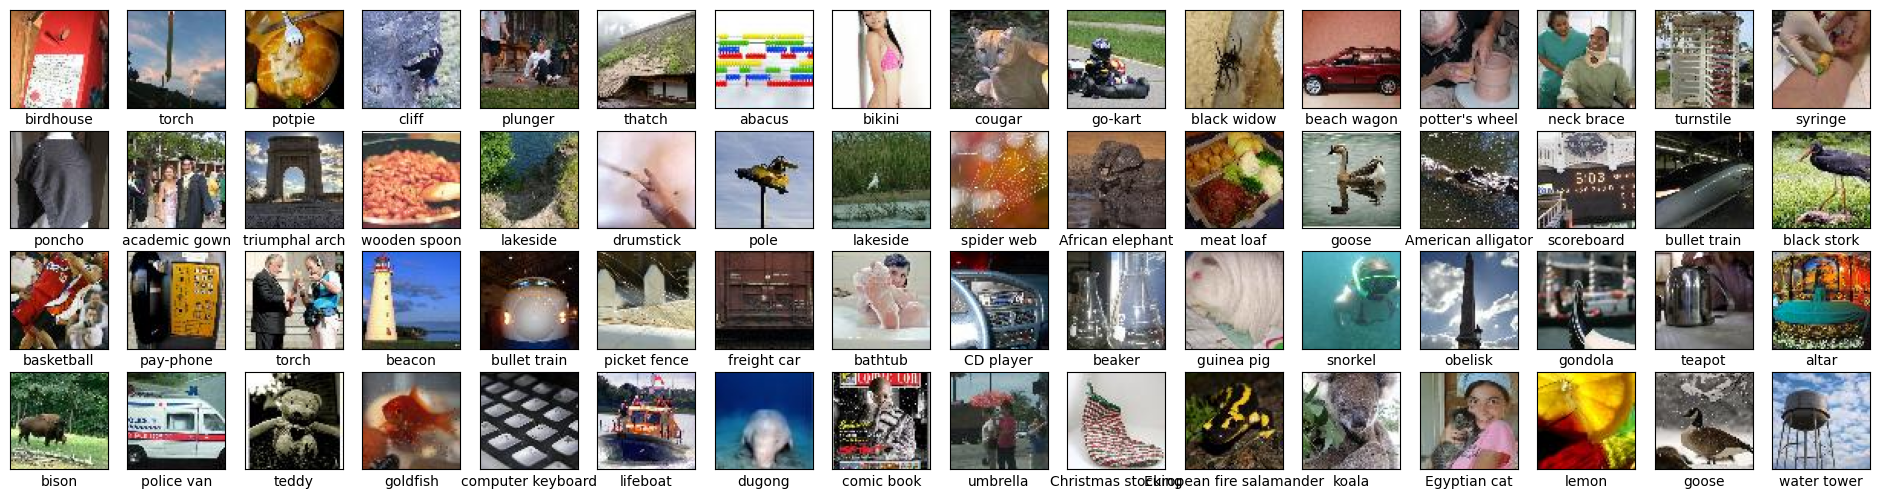

In [ ]:
"""
NOTE: THIS BLOCK IS FOR VISUALIZATION PURPOSE ONLY
"""

visualization_transform = v2.Compose([
    v2.ToImage(),
    v2.RGB(),
    v2.ToDtype(torch.float32, scale=True),
])

batch_size = 64

train_loader, _ = get_train_test_dataloader(
    batch_size=batch_size, 
    num_workers=4, 
    transform=visualization_transform
)

class_id = train_loader.dataset.info.features['label'].names # Get the mapping from label indices to class IDs (e.g., 0 -> 'n01443537')

label_dict = {}
with open("labels.txt", "r") as f: # Load the provided labels.txt that maps from class IDs to human-readable labels (e.g., 'n01443537' -> 'goldfish')
    for line in tqdm(f):
        id, label = line.split("\t")
        label_dict[id.strip()] = label.split(",")[0].strip() # Use the first label if there are multiple labels for a class

train_images, train_labels = next(iter(train_loader))
visualize_data(
    images=train_images,
    categories=[class_id[label] for label in train_labels], class_names=label_dict, 
    images_per_row=16,
)

In [6]:
batch_size = 64
transform = None # Define your own transform pipeline, otherwise it will default to the transform inside `get_train_test_dataloader` 
train_loader, test_loader = get_train_test_dataloader(batch_size=batch_size, num_workers=4, transform=transform)

# Task 1 - Baseline CNN model (4 marks)

In [ ]:
# ============================================================
# Task 1: Baseline CNN
# ============================================================
import os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchinfo import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 200
os.makedirs('checkpoints', exist_ok=True)
print(f"Using device: {device}")


# ---------- Shared training utilities ----------
def evaluate(model, loader, criterion=None):
    if criterion is None:
        criterion = nn.CrossEntropyLoss(reduction='sum')
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
            out = model(x)
            loss_sum += criterion(out, y).item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_sum / total, correct / total


def train_model(model, train_loader, test_loader, epochs=15, lr=1e-3, weight_decay=0.0,
                use_sgd=False, momentum=0.9, scheduler=None, criterion=None,
                mixup_fn=None, save_path=None, label_smoothing=0.0):
    """Generic training loop: supports Adam/SGD, cosine LR, MixUp, label smoothing, checkpoint saving."""
    if criterion is None:
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    if use_sgd:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum,
                              weight_decay=weight_decay, nesterov=True)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if scheduler == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    eval_crit = nn.CrossEntropyLoss(reduction='sum')

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_acc = 0.0
    for ep in range(epochs):
        model.train()
        ls, c, t = 0.0, 0, 0
        for x, y in train_loader:
            x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
            optimizer.zero_grad()
            if mixup_fn is not None:
                xm, ya, yb, lam = mixup_fn(x, y)
                out = model(xm)
                loss = lam * criterion(out, ya) + (1 - lam) * criterion(out, yb)
            else:
                out = model(x)
                loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            ls += loss.item() * y.size(0)
            c += (out.argmax(1) == y).sum().item()
            t += y.size(0)
        if scheduler is not None:
            scheduler.step()
        tr_loss, tr_acc = ls / t, c / t
        te_loss, te_acc = evaluate(model, test_loader, eval_crit)
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss); history['test_acc'].append(te_acc)
        if te_acc > best_acc:
            best_acc = te_acc
            if save_path is not None:
                torch.save(model.state_dict(), save_path)
        print(f"Ep {ep+1:2d}/{epochs}: tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | te_loss={te_loss:.4f} te_acc={te_acc:.4f}")
    return history, best_acc


def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    eps = range(1, len(history['train_loss']) + 1)
    axes[0].plot(eps, history['train_loss'], label='train')
    axes[0].plot(eps, history['test_loss'], label='test')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(eps, history['train_acc'], label='train')
    axes[1].plot(eps, history['test_acc'], label='test')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Top-1 Accuracy')
    axes[1].set_title(f'{title} - Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


# ---------- Baseline architecture ----------
class BaselineCNN(nn.Module):
    """Conv(16,7) -> Pool -> Conv(32,5,p=2) -> Pool -> Conv(32,5,p=2) -> Pool -> FC(196) -> FC(200)."""
    def __init__(self, num_classes=200):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=7, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, stride=1, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 196)
        self.fc2 = nn.Linear(196, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


baseline = BaselineCNN().to(device)
summary(baseline, input_size=(1, 3, 64, 64))

history_baseline, best_baseline = train_model(
    baseline, train_loader, test_loader, epochs=15, lr=1e-3
)
print(f"\nBaseline best Top-1 test accuracy: {best_baseline*100:.2f}%")
plot_history(history_baseline, 'Task 1 Baseline')


# Task 2 - Improve the baseline model from Task 1 (7 marks)

In [ ]:
# ============================================================
# Task 2: Improve the baseline (Task 1) one technique at a time.
#
# Baseline (Task 1) layout:
#   Conv(3->16, 7x7)   -> ReLU -> MaxPool   # (16, 29, 29)
#   Conv(16->32, 5x5, p=2) -> ReLU -> MaxPool   # (32, 14, 14)
#   Conv(32->32, 5x5, p=2) -> ReLU -> MaxPool   # (32, 7, 7)
#   Flatten -> Linear 1568 -> 196 -> ReLU -> Linear 196 -> 200
#
# Every variant below keeps the same 3-stage + FC head skeleton and only
# changes the technique under study (data, normalisation, kernels, depth/pool,
# residual blocks, inception modules). 2 variants per sub-task; 6 epochs each.
# ============================================================
from torchvision.transforms import v2 as T
T2_EPOCHS = 6


def run_variant(name, model, train_l=None, test_l=None, epochs=T2_EPOCHS, lr=1e-3, **kw):
    """Print summary, train, plot, and return the best test accuracy."""
    train_l = train_l if train_l is not None else train_loader
    test_l = test_l if test_l is not None else test_loader
    print(f"\n--- {name} ---")
    summary(model, input_size=(1, 3, 64, 64), depth=2,
            col_names=['output_size', 'num_params'], verbose=1)
    h, ba = train_model(model.to(device), train_l, test_l, epochs=epochs, lr=lr, **kw)
    print(f"{name}: best test accuracy = {ba*100:.2f}%")
    plot_history(h, name)
    return ba


# ============================================================
# 2.1 Data augmentation (1 mark)
# Same BaselineCNN architecture, different training data pipeline.
# ============================================================
print("\n========== Task 2.1: Data Augmentation ==========")

def make_aug_loader(aug_list, batch_size=64):
    tf = T.Compose([T.ToImage(), T.RGB(), T.ToDtype(torch.float32, scale=True),
                    *aug_list,
                    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    tr, _ = get_train_test_dataloader(batch_size=batch_size, num_workers=4, transform=tf)
    return tr

aug_loader_a = make_aug_loader([T.RandomHorizontalFlip(), T.RandomCrop(64, padding=4)])
aug_loader_b = make_aug_loader([T.RandomHorizontalFlip(), T.RandomCrop(64, padding=4),
                                T.ColorJitter(0.2, 0.2, 0.2)])

acc_2_1_a = run_variant("2.1A baseline + flip+crop", BaselineCNN(), train_l=aug_loader_a)
acc_2_1_b = run_variant("2.1B baseline + flip+crop+jitter", BaselineCNN(), train_l=aug_loader_b)


# ============================================================
# 2.2 Normalization + Dropout layers (1 mark)
# Same baseline conv/FC layout, with BN inserted after each conv (and
# optional dropout in the head).
# ============================================================
print("\n========== Task 2.2: BatchNorm + Dropout ==========")

class BaselineBNDrop(nn.Module):
    """Baseline architecture with BatchNorm after every conv and dropout in the FC head."""
    def __init__(self, p_drop=0.0, num_classes=200):
        super().__init__()
        self.b1 = nn.Sequential(nn.Conv2d(3, 16, 7),  nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2))
        self.b2 = nn.Sequential(nn.Conv2d(16, 32, 5, padding=2), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.b3 = nn.Sequential(nn.Conv2d(32, 32, 5, padding=2), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(32*7*7, 196), nn.ReLU(),
                                  nn.Dropout(p_drop), nn.Linear(196, num_classes))
    def forward(self, x): return self.head(self.b3(self.b2(self.b1(x))))

acc_2_2_a = run_variant("2.2A baseline + BN", BaselineBNDrop(p_drop=0.0))
acc_2_2_b = run_variant("2.2B baseline + BN + Dropout(0.5)", BaselineBNDrop(p_drop=0.5))


# ============================================================
# 2.3 Modify convolution kernel sizes / number of filters (1 mark)
# Keep the baseline's 3-conv + 3-pool + FC-head layout. Only change the
# kernel sizes (variant A) or filter counts (variant B).
# ============================================================
print("\n========== Task 2.3: Kernel sizes / Filter counts ==========")

class BaselineModKernels(nn.Module):
    """Baseline structure with configurable kernel sizes and channel widths.
    Padding is set per-conv so the output spatial sizes after the 3 maxpools
    remain (c, 7, 7) -- matching the baseline.
    """
    def __init__(self, kernels=(7, 5, 5), channels=(16, 32, 32), num_classes=200):
        super().__init__()
        k1, k2, k3 = kernels
        c1, c2, c3 = channels
        # First conv: no padding (shrinks 64 -> 64-k1+1, like baseline 64->58)
        self.conv1 = nn.Conv2d(3, c1, k1)
        # Subsequent convs: padding to preserve spatial size
        self.conv2 = nn.Conv2d(c1, c2, k2, padding=k2 // 2)
        self.conv3 = nn.Conv2d(c2, c3, k3, padding=k3 // 2)
        self.pool = nn.MaxPool2d(2, 2)
        # Spatial size after stem-conv: 64-k1+1; then 3 maxpools.
        s = (64 - k1 + 1) // 2 // 2 // 2
        self.fc1 = nn.Linear(c3 * s * s, 196)
        self.fc2 = nn.Linear(196, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Variant A: smaller 3x3 kernels, baseline channel widths
acc_2_3_a = run_variant("2.3A baseline + 3x3 kernels",
                        BaselineModKernels(kernels=(3, 3, 3), channels=(16, 32, 32)))
# Variant B: baseline kernels, more filters
acc_2_3_b = run_variant("2.3B baseline + wider filters (32,64,64)",
                        BaselineModKernels(kernels=(7, 5, 5), channels=(32, 64, 64)))


# ============================================================
# 2.4 Add depth + experiment with final pooling (1 mark)
# Take the baseline, append one more 3x3 conv block, then test two
# pooling strategies for the final feature maps before the FC head.
# ============================================================
print("\n========== Task 2.4: Deeper + Pooling Strategy ==========")

class BaselineDeeper(nn.Module):
    """Baseline + one extra conv block, with selectable head pooling.

    final_pool='flatten'  -> additional MaxPool then Flatten (smaller features)
    final_pool='gap'      -> AdaptiveAvgPool2d(1) (one feature per channel)
    """
    def __init__(self, final_pool='flatten', num_classes=200):
        super().__init__()
        # Same first 3 stages as baseline
        self.conv1 = nn.Conv2d(3, 16, 7)
        self.conv2 = nn.Conv2d(16, 32, 5, padding=2)
        self.conv3 = nn.Conv2d(32, 32, 5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        # Extra (4th) conv block, operating on the (32, 7, 7) feature maps
        self.conv4 = nn.Conv2d(32, 32, 3, padding=1)
        if final_pool == 'flatten':
            # Pool 7 -> 3, then flatten 32*3*3 = 288
            self.tail = nn.Sequential(nn.MaxPool2d(2, 2), nn.Flatten())
            in_feats = 32 * 3 * 3
        else:  # 'gap'
            self.tail = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten())
            in_feats = 32
        self.fc1 = nn.Linear(in_feats, 196)
        self.fc2 = nn.Linear(196, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = F.relu(self.conv4(x))
        x = self.tail(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

acc_2_4_a = run_variant("2.4A baseline + extra conv + Flatten", BaselineDeeper(final_pool='flatten'))
acc_2_4_b = run_variant("2.4B baseline + extra conv + GAP",     BaselineDeeper(final_pool='gap'))


# ============================================================
# 2.5 Residual blocks (1.5 marks)
# Keep the baseline stem (Conv 7x7 -> ReLU -> MaxPool) and the FC head
# unchanged. Replace the second and third conv layers with residual
# blocks. Variant A uses 1 block per stage, variant B uses 2.
# ============================================================
print("\n========== Task 2.5: Residual Blocks ==========")

class ResBlock(nn.Module):
    """Residual block at fixed spatial size.
    Two conv-BN layers with a ReLU between, plus 1x1 projection shortcut
    when the channel count changes.
    """
    def __init__(self, c_in, c_out, kernel=5, padding=2):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in,  c_out, kernel, padding=padding, bias=False)
        self.bn1   = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, kernel, padding=padding, bias=False)
        self.bn2   = nn.BatchNorm2d(c_out)
        self.short = (nn.Identity() if c_in == c_out else
                      nn.Sequential(nn.Conv2d(c_in, c_out, 1, bias=False),
                                    nn.BatchNorm2d(c_out)))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.short(x))


class BaselineResidual(nn.Module):
    """Baseline stem + residual blocks in place of conv2/conv3 + baseline FC head."""
    def __init__(self, n_per_stage=1, num_classes=200):
        super().__init__()
        # Baseline stem: Conv(3->16, 7x7) -> BN -> ReLU -> MaxPool
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 7), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        # Stage 1 replaces baseline conv2 (16 -> 32) at the (29x29) feature map
        s1 = [ResBlock(16, 32)] + [ResBlock(32, 32) for _ in range(n_per_stage - 1)]
        self.stage1 = nn.Sequential(*s1, nn.MaxPool2d(2, 2))
        # Stage 2 replaces baseline conv3 (32 -> 32) at the (14x14) feature map
        s2 = [ResBlock(32, 32) for _ in range(n_per_stage)]
        self.stage2 = nn.Sequential(*s2, nn.MaxPool2d(2, 2))
        # Same FC head as baseline
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(32*7*7, 196), nn.ReLU(),
                                  nn.Linear(196, num_classes))
    def forward(self, x):
        return self.head(self.stage2(self.stage1(self.stem(x))))

acc_2_5_a = run_variant("2.5A baseline + residual (1 block/stage)", BaselineResidual(n_per_stage=1))
acc_2_5_b = run_variant("2.5B baseline + residual (2 blocks/stage)", BaselineResidual(n_per_stage=2))


# ============================================================
# 2.6 Inception modules (1.5 marks)
# Same idea as 2.5: keep baseline stem and FC head, but replace conv2/conv3
# with inception modules. Variants change the inception output width.
# ============================================================
print("\n========== Task 2.6: Inception Modules ==========")

class InceptionModule(nn.Module):
    """Inception module producing exactly c_out channels.
    Branches: 1x1, 1x1->3x3, 1x1->5x5, pool->1x1, all concatenated.
    """
    def __init__(self, c_in, c_out):
        super().__init__()
        c1 = c_out // 4
        c3 = c_out // 4
        c5 = c_out // 4
        cp = c_out - 3 * (c_out // 4)
        c3r = max(c_in // 2, 4)
        c5r = max(c_in // 4, 4)
        self.b1 = nn.Sequential(nn.Conv2d(c_in, c1, 1), nn.BatchNorm2d(c1), nn.ReLU())
        self.b3 = nn.Sequential(nn.Conv2d(c_in, c3r, 1), nn.BatchNorm2d(c3r), nn.ReLU(),
                                nn.Conv2d(c3r, c3, 3, padding=1), nn.BatchNorm2d(c3), nn.ReLU())
        self.b5 = nn.Sequential(nn.Conv2d(c_in, c5r, 1), nn.BatchNorm2d(c5r), nn.ReLU(),
                                nn.Conv2d(c5r, c5, 5, padding=2), nn.BatchNorm2d(c5), nn.ReLU())
        self.bp = nn.Sequential(nn.MaxPool2d(3, 1, 1),
                                nn.Conv2d(c_in, cp, 1), nn.BatchNorm2d(cp), nn.ReLU())
    def forward(self, x):
        return torch.cat([self.b1(x), self.b3(x), self.b5(x), self.bp(x)], dim=1)


class BaselineInception(nn.Module):
    """Baseline stem + inception modules in place of conv2/conv3 + baseline FC head."""
    def __init__(self, c_mid=32, c_out=32, num_classes=200):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 7), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        # Stage 1: inception 16 -> c_mid (replaces conv2)
        self.stage1 = nn.Sequential(InceptionModule(16, c_mid), nn.MaxPool2d(2, 2))
        # Stage 2: inception c_mid -> c_out (replaces conv3)
        self.stage2 = nn.Sequential(InceptionModule(c_mid, c_out), nn.MaxPool2d(2, 2))
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(c_out * 7 * 7, 196), nn.ReLU(),
                                  nn.Linear(196, num_classes))
    def forward(self, x):
        return self.head(self.stage2(self.stage1(self.stem(x))))

acc_2_6_a = run_variant("2.6A baseline + inception (32, 32)", BaselineInception(c_mid=32, c_out=32))
acc_2_6_b = run_variant("2.6B baseline + inception (64, 64)", BaselineInception(c_mid=64, c_out=64))


# ---------- Summary table ----------
print("\n========== Task 2 Summary ==========")
print(f"{'Variant':<42s} {'Best Test Acc':>14s}")
results_t2 = [
    ("2.1A baseline + flip+crop",                 acc_2_1_a),
    ("2.1B baseline + flip+crop+jitter",          acc_2_1_b),
    ("2.2A baseline + BN",                        acc_2_2_a),
    ("2.2B baseline + BN + Dropout(0.5)",         acc_2_2_b),
    ("2.3A baseline + 3x3 kernels",               acc_2_3_a),
    ("2.3B baseline + wider filters (32,64,64)",  acc_2_3_b),
    ("2.4A baseline + extra conv + Flatten",      acc_2_4_a),
    ("2.4B baseline + extra conv + GAP",          acc_2_4_b),
    ("2.5A baseline + residual (1/stage)",        acc_2_5_a),
    ("2.5B baseline + residual (2/stage)",        acc_2_5_b),
    ("2.6A baseline + inception (32, 32)",        acc_2_6_a),
    ("2.6B baseline + inception (64, 64)",        acc_2_6_b),
]
for name, a in results_t2:
    print(f"{name:<42s} {a*100:>13.2f}%")


# Task 3 - Find the best model (5 marks)

In [ ]:
# ============================================================
# Task 3: Best model
# Combines Task 2 techniques: data augmentation (flip+crop+jitter),
# BatchNorm + dropout, all-3x3 kernels with wider filters, 4 stages
# with global average pooling head, and residual blocks.
# Trained from scratch with SGD + Nesterov + cosine LR.
# ============================================================
TASK3_CKPT = 'checkpoints/task3_best.pt'

class BestResNet(nn.Module):
    """4-stage manual ResNet (no torchvision backbone). Combines techniques from Task 2."""
    def __init__(self, num_classes=200, blocks=(2, 2, 2, 2),
                 channels=(64, 128, 256, 512), drop=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, channels[0], 3, padding=1, bias=False),
            nn.BatchNorm2d(channels[0]), nn.ReLU(inplace=True))
        layers, cin = [], channels[0]
        for i, n in enumerate(blocks):
            for j in range(n):
                stride = 2 if (j == 0 and i > 0) else 1
                layers.append(BasicBlock(cin, channels[i], stride=stride))
                cin = channels[i]
        self.body = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(drop), nn.Linear(cin, num_classes))
    def forward(self, x): return self.head(self.body(self.stem(x)))


# Augmented training loader (flip + crop + colour jitter), test loader unchanged
t3_train_tf = T.Compose([
    T.ToImage(), T.RGB(), T.ToDtype(torch.float32, scale=True),
    T.RandomHorizontalFlip(),
    T.RandomCrop(64, padding=4),
    T.ColorJitter(0.2, 0.2, 0.2),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
t3_train_loader, t3_test_loader = get_train_test_dataloader(
    batch_size=128, num_workers=4, transform=t3_train_tf)

# Show summary and parameter count (must be < 40M)
best_model = BestResNet().to(device)
summary(best_model, input_size=(1, 3, 64, 64))

# Train (or skip if a checkpoint already exists)
if not os.path.exists(TASK3_CKPT):
    history_t3, best_acc_t3 = train_model(
        best_model, t3_train_loader, t3_test_loader,
        epochs=35, lr=0.1, use_sgd=True, momentum=0.9,
        weight_decay=5e-4, scheduler='cosine', save_path=TASK3_CKPT,
    )
    plot_history(history_t3, 'Task 3 Best Model')
    print(f"\nTask 3 best Top-1 test accuracy (during training): {best_acc_t3*100:.2f}%")
else:
    print(f"Found existing checkpoint at {TASK3_CKPT}; skipping training.")

# ---- Required cell: instantiate architecture and load checkpoint ----
best_model = BestResNet().to(device)
best_model.load_state_dict(torch.load(TASK3_CKPT, map_location=device))
te_loss, te_acc = evaluate(best_model, t3_test_loader)
print(f"Task 3 final Top-1 test accuracy (loaded from checkpoint): {te_acc*100:.2f}%")


# Task 4 - Explore image classification (4 marks)

In [ ]:
# ============================================================
# Task 4: Approaches beyond Task 2/3.
# New techniques (not used in Task 2):
#   1. Squeeze-and-Excitation channel attention (Hu et al., CVPR 2018).
#   2. MixUp data regularisation (Zhang et al., ICLR 2018).
#   3. Label smoothing (Szegedy et al., CVPR 2016).
# Backbone is the same residual stack as Task 3, with SE inserted in each block.
# ============================================================
TASK4_CKPT = 'checkpoints/task4_best.pt'


class SEBlock(nn.Module):
    """Squeeze-and-Excitation: per-channel reweighting via global pooling + 2-layer MLP + sigmoid."""
    def __init__(self, c, r=16):
        super().__init__()
        h = max(c // r, 1)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(c, h), nn.ReLU(inplace=True),
            nn.Linear(h, c), nn.Sigmoid())
    def forward(self, x):
        s = self.fc(x).view(x.size(0), x.size(1), 1, 1)
        return x * s


class SEBasicBlock(nn.Module):
    """ResNet basic block with an SE module inserted before the residual addition."""
    def __init__(self, c_in, c_out, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c_out)
        self.se = SEBlock(c_out)
        if stride == 1 and c_in == c_out:
            self.short = nn.Identity()
        else:
            self.short = nn.Sequential(
                nn.Conv2d(c_in, c_out, 1, stride=stride, bias=False),
                nn.BatchNorm2d(c_out))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        return F.relu(out + self.short(x))


class SEResNet(nn.Module):
    """Same 4-stage layout as the Task 3 model but using SE basic blocks."""
    def __init__(self, num_classes=200, blocks=(2, 2, 2, 2),
                 channels=(64, 128, 256, 512), drop=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, channels[0], 3, padding=1, bias=False),
            nn.BatchNorm2d(channels[0]), nn.ReLU(inplace=True))
        layers, cin = [], channels[0]
        for i, n in enumerate(blocks):
            for j in range(n):
                stride = 2 if (j == 0 and i > 0) else 1
                layers.append(SEBasicBlock(cin, channels[i], stride=stride))
                cin = channels[i]
        self.body = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(drop), nn.Linear(cin, num_classes))
    def forward(self, x): return self.head(self.body(self.stem(x)))


def mixup_data(x, y, alpha=0.2):
    """MixUp: linearly interpolate two random samples and their (one-hot) labels."""
    if alpha > 0:
        lam = float(torch.distributions.Beta(alpha, alpha).sample())
    else:
        lam = 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


t4_model = SEResNet().to(device)
summary(t4_model, input_size=(1, 3, 64, 64))

if not os.path.exists(TASK4_CKPT):
    history_t4, best_acc_t4 = train_model(
        t4_model, t3_train_loader, t3_test_loader,
        epochs=40, lr=0.1, use_sgd=True, momentum=0.9,
        weight_decay=5e-4, scheduler='cosine',
        label_smoothing=0.1, mixup_fn=mixup_data,
        save_path=TASK4_CKPT,
    )
    plot_history(history_t4, 'Task 4 Model (SE + MixUp + Label Smoothing)')
    print(f"\nTask 4 best Top-1 test accuracy (during training): {best_acc_t4*100:.2f}%")
else:
    print(f"Found existing checkpoint at {TASK4_CKPT}; skipping training.")

# ---- Required cell: instantiate architecture and load checkpoint ----
t4_model = SEResNet().to(device)
t4_model.load_state_dict(torch.load(TASK4_CKPT, map_location=device))
te_loss, te_acc = evaluate(t4_model, t3_test_loader)
print(f"Task 4 final Top-1 test accuracy (loaded from checkpoint): {te_acc*100:.2f}%")
